### Correlacion entre datos

correlacion fuerte : 0.7-1
correlacion moderada: 0.4 - 0.7
correlacion debil: 0.1 - 0.4
sin correlacion: 0 - 0.1
 visualmente se puede ver por que tan disperso estan. si estan muy juntos los datos estan fuertemente relacionado y si hy unos especificos que se salen de la forma de la dispercion, son outliers

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
n_personas=15
data={  
    'horas_sueño':np.random.uniform(5,9,n_personas),
    'cafes_por_dia':np.random.randint(0,6,n_personas),
    'uso_pantallas_hs':np.random.uniform(2,10,n_personas),
    'min_ejercicio':np.random.uniform(0,60,n_personas)
}

data['nivel_concentracion']=( 0.5*data['horas_sueño']+0.2*data['min_ejercicio']-0.3*data['uso_pantallas_hs']+np.random.normal(0,1,n_personas))
df=pd.DataFrame(data)
df

,horas_sueño,cafes_por_dia,uso_pantallas_hs,min_ejercicio,nivel_concentracion
0,7.986834,4,9.788242,26.523232,6.297812
1,5.498797,0,5.761268,55.444359,13.476714
2,6.658622,3,8.083682,15.585095,2.530006
3,8.843505,4,8.562278,36.570063,8.749862
4,8.252704,3,3.348865,22.759389,7.418734
5,8.651541,0,5.603975,45.908696,11.175246
6,5.722171,5,3.518867,6.725702,2.868731
7,5.855019,2,8.906427,16.623668,2.363785
8,5.799761,5,8.429418,45.540896,7.602819
9,6.800828,5,7.641228,31.733562,7.069679


In [ ]:
correlacion1=df.corr()#por defecto es method='pearson' lineal
correlacion1

,horas_sueño,cafes_por_dia,uso_pantallas_hs,min_ejercicio,nivel_concentracion
horas_sueño,1.000000,0.006638,0.229443,-0.010322,0.118846
cafes_por_dia,0.006638,1.000000,0.127844,-0.195909,-0.228321
uso_pantallas_hs,0.229443,0.127844,1.000000,0.023377,-0.292375
min_ejercicio,-0.010322,-0.195909,0.023377,1.000000,0.897296
nivel_concentracion,0.118846,-0.228321,-0.292375,0.897296,1.000000


In [ ]:
correlacion2=df.corr(method='spearman') #metodo spearman para no lineal
correlacion2

,horas_sueño,cafes_por_dia,uso_pantallas_hs,min_ejercicio,nivel_concentracion
horas_sueño,1.000000,0.049420,0.246429,0.057143,0.110714
cafes_por_dia,0.049420,1.000000,0.133618,-0.054912,-0.078707
uso_pantallas_hs,0.246429,0.133618,1.000000,-0.007143,-0.328571
min_ejercicio,0.057143,-0.054912,-0.007143,1.000000,0.889286
nivel_concentracion,0.110714,-0.078707,-0.328571,0.889286,1.000000


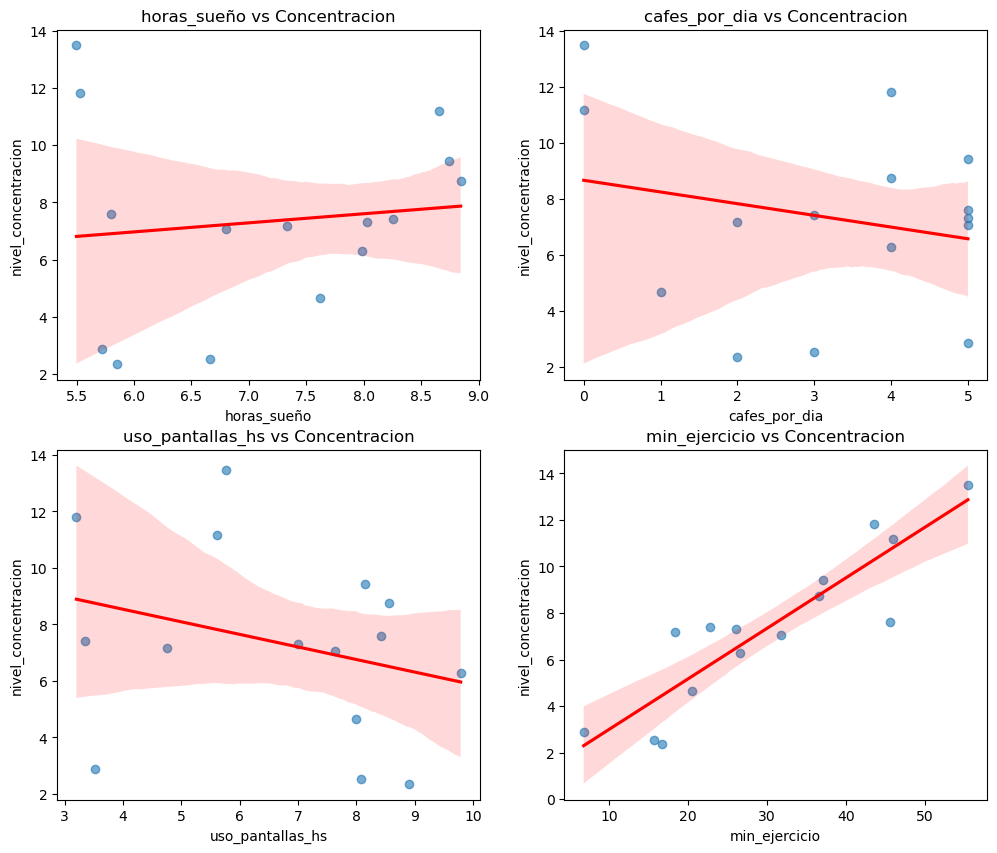

In [15]:
#representar graficamente con scatterplots
variables_predictoras=['horas_sueño','cafes_por_dia','uso_pantallas_hs','min_ejercicio']

fig,axes=plt.subplots(2,2,figsize=(12,10))
axes= axes.flatten()

for i,var in enumerate(variables_predictoras):
    sns.regplot(ax=axes[i],x=df[var],y=df['nivel_concentracion'],scatter_kws={'alpha':0.6},line_kws={'color':'red'})
    axes[i].set_title(f'{var} vs Concentracion')

plt.tight_layout
plt.show()

In [18]:
correlacion_nc=df.corr()['nivel_concentracion'].sort_values(ascending=False)
correlacion_nc

nivel_concentracion    1.000000
min_ejercicio          0.897296
horas_sueño            0.118846
cafes_por_dia         -0.228321
uso_pantallas_hs      -0.292375
Name: nivel_concentracion, dtype: float64

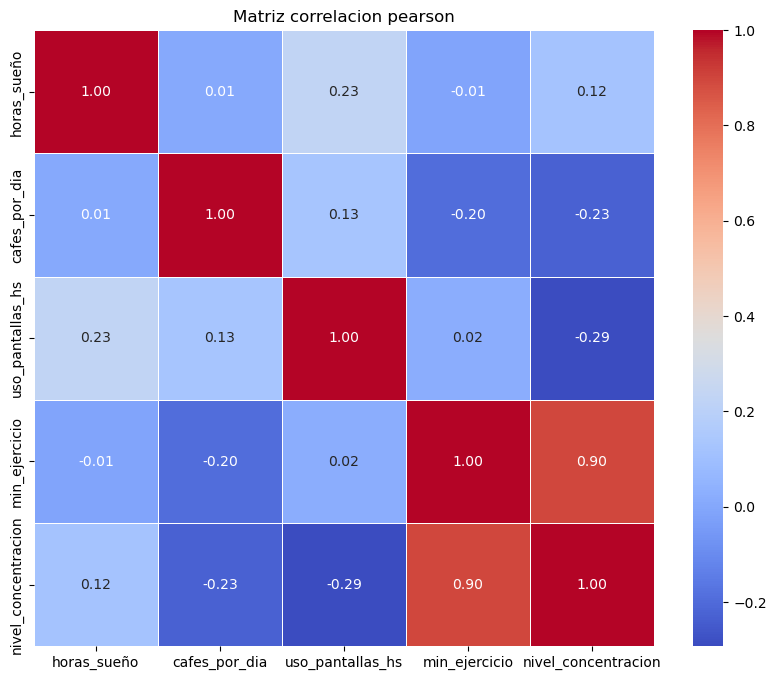

In [19]:
#visualizar por heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlacion1,annot=True, cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title("Matriz correlacion pearson")
plt.show()

In [21]:
pip install pingouin

Note: you may need to restart the kernel to use updated packages.


caso:se asumio una correlacion media alta de horas_sueño para explicar la correlacion parcial
nivel_concentracion    1.000000
min_ejercicio          0.897296
horas_sueño            0.618846
cafes_por_dia         -0.228321
uso_pantallas_hs      -0.292375
 

In [22]:
import pingouin as pg

In [29]:
import pingouin as pg

# Ejercicio controlando sueño
pg.partial_corr(data=df,
                x='min_ejercicio',
                y='nivel_concentracion',
                covar='horas_sueño')



,n,r,CI95,p_val
pearson,15,0.904985,"[0.72, 0.97]",0.000009


1. Interpretación del coeficiente r
r = 0.904985

Es una correlación muy alta y positiva
Incluso controlando horas_sueño

2. Comparación mental con la correlación simple

Tú tenías antes:

Correlación simple: ~ 0.897
Correlación parcial: 0.905
conclusion:El sueño no estaba explicando la relación entre ejercicio y concentración

3. Intervalo de confianza (CI95)

👉 [0.72, 0.97]

Esto significa:

Con 95% de confianza, la correlación real está entre 0.72 y 0.97 Todo el intervalo es positivo y alto
4. p-value

👉 p_val = 0.000009

Es mucho menor que 0.05 La correlación es estadísticamente significativa
Existe una correlación positiva fuerte (r ≈ 0.90) entre min_ejercicio y nivel_concentracion, incluso al controlar por horas_sueño. Esto indica que el ejercicio tiene un efecto significativo e independiente sobre la concentración. Además, la relación es estadísticamente significativa (p < 0.05) y el intervalo de confianza confirma la robustez del resultado.

In [30]:
# Sueño controlando ejercicio
pg.partial_corr(data=df,
                x='horas_sueño',
                y='nivel_concentracion',
                covar='min_ejercicio')

,n,r,CI95,p_val
pearson,15,0.290227,"[-0.28, 0.71]",0.314142


Antes tenías:
r = 0.29 Correlación débil positiva

Correlación simple: 0.618
Correlación parcial: 0.290

👉 Bajó bastante ❗

✔️ Conclusión:

Gran parte de la relación entre sueño y concentración estaba influenciada por el ejercicio
[-0.28, 0.71]

Incluye el 0
✔️ Esto significa:

No hay evidencia clara de una relación real
4. p-value

👉 p_val = 0.314

Es mayor que 0.05
Comparación completa:
min_ejercicio:
r ≈ 0.90 (alto, significativo, independiente) ✅
horas_sueño:
r ≈ 0.29 (bajo, no significativo) ❌

El min_ejercicio es la variable que realmente explica la concentración.
La relación observada entre horas_sueño y nivel_concentracion estaba influenciada por el ejercicio, y al controlar este efecto, dicha relación pierde fuerza y deja de ser significativa.


Conclusion:
se concluye que 'horas_sueño' no es independiente y min_ejercicio mantiene una relacion alta mostrando que es el factor principal de la variable objetivo
Aunque varias variables parecen relacionadas con la concentración, solo el ejercicio tiene un efecto fuerte e independiente.
NO hay que andar modificando las correlaciones 
hasta ahora solo se vieron las correlaciones con la variable objetivo

In [ ]:
#controlar varias variables a la vez:
pg.partial_corr(data=df,
                x='min_ejercicio',
                y='nivel_concentracion',
                covar=['horas_sueño', 'cafes_por_dia', 'uso_pantallas_hs'])